# Section 1 - Background/Motivation

In traditional portfolio optimization, Mean-Variance Optimization (MVO) is often used as a benchmark for portfolio efficiency. Its reliance on single-point estimates of returns and covariances can make it sensitive to input errors; this limitation can be addressed by Monte Carlo simulation, which evaluates portfolio performance across a wide range of randomly generated scenarios. 

The end goal of both this is to create a diversified portfolio that is able to generate returns during volatile periods with the core intution being that when one stock performs poorly, the portfolio should have another asset to accomodate for that. The end goal of both approaches is to create a diversified portfolio that can generate stable returns even during volatile periods, based on the intuition that when one asset underperforms, others in the portfolio can offset the loss.

This raises the question of how a ‘diversified portfolio’ should be defined, and whether stocks from the same industry reduce diversification benefits. This project aims to use network analysis on Fortune 500 companies to explore whether incorporating network relationships into portfolio construction can lead to improved risk-adjusted outcomes.



# Section 2 - Data/Setup

**Company Information:** Company information such as ticker symbol and industry will be taken from this Kaggle dataset: https://www.kaggle.com/datasets/jeannicolasduval/2024-fortune-1000-companies




In [3]:
import pandas as pd

# read in company information
company_info = pd.read_csv("archive/fortune1000_2024.csv").head(500)

print(company_info.shape)
company_info.head()

(500, 32)


,Rank,Company,Ticker,Sector,Industry,Profitable,Founder_is_CEO,FemaleCEO,Growth_in_Jobs,Change_in_Rank,...,Assets_M,CEO,Country,HeadquartersCity,HeadquartersState,Website,CompanyType,Footnote,MarketCap_Updated_M,Updated
0,1,Walmart,WMT,Retailing,General Merchandisers,yes,no,no,no,0.0,...,252399.0,C. Douglas McMillon,U.S.,Bentonville,Arkansas,https://www.stock.walmart.com,Public,"Figures are for fiscal year ended Jan. 31, 202...",559911.0,2024-08-05
1,2,Amazon,AMZN,Retailing,Internet Services and Retailing,yes,no,no,no,0.0,...,527854.0,Andrew R. Jassy,U.S.,Seattle,Washington,https://www.amazon.com,Public,"Market value as of July 15, 2024.",2005565.0,2024-08-05
2,3,Apple,AAPL,Technology,"Computers, Office Equipment",yes,no,no,no,1.0,...,352583.0,Timothy D. Cook,U.S.,Cupertino,California,https://www.apple.com,Public,"Figures are for fiscal year ended Sept. 30, 20...",3594309.0,2024-08-05
3,4,UnitedHealth Group,UNH,Health Care,Health Care: Insurance and Managed Care,yes,no,no,yes,1.0,...,273720.0,Andrew P. Witty,U.S.,Minnetonka,Minnesota,https://www.unitedhealthgroup.com,Public,"Market value as of July 15, 2024.",474339.0,2024-08-05
4,5,Berkshire Hathaway,BRKA,Financials,Insurance: Property and Casualty (Stock),yes,no,no,yes,2.0,...,1069978.0,Warren E. Buffett,U.S.,Omaha,Nebraska,https://www.berkshirehathaway.com,Public,"Market value as of July 15, 2024.",937028.0,2024-08-05


## Section 2.1: Data Source

**Stock Prices**: Stock prices will be the *yFinance* package from Python. We can define a training time period to include stock prices from the fiscal year 2023 and a testing time period to be the fiscal year 2024. For this anlaysis closing prices will be used



In [33]:
import yfinance as yf
import pandas as pd

# Prepare tickers
tickers = company_info['Ticker'].dropna().astype(str).tolist()

# Clean the list to all tickers work with yfinance
list_to_drop = ['NYCB', 'CLR', 'GPS', 'PXD', 'BECN', 'SQ', 'HES', 'DFS', 'RADCQ', 'SKX', 'QRTEA', 'X', 'WBA', 'LSXMA', 'JWN', 'BERY', 'BRKA', 'SPTN', 'PARA', 'CHK', 'FL']
for ticker in tickers:
    if ticker in list_to_drop:
        tickers.remove(ticker)


# Download closing prices
data_2023 = yf.download(tickers, start="2023-01-01", end="2023-12-31")['Close']
data_2024 = yf.download(tickers, start="2024-01-01", end="2024-12-31")['Close']

data_2023 = data_2023.dropna(axis=1, how='all')
data_2024 = data_2024.dropna(axis=1, how='all')

returns_2023 = data_2023.pct_change(fill_method=None).dropna()
returns_2024 = data_2024.pct_change(fill_method=None).dropna()

print(returns_2023.head())
print(returns_2024.head())

returns_2023.to_csv("returns_2023.csv")
returns_2024.to_csv("returns_2024.csv")



/var/folders/47/v7qz91k96hsgbdpq8zqrwxj00000gn/T/ipykernel_87466/4190116575.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2023 = yf.download(tickers, start="2023-01-01", end="2023-12-31")['Close']
[*********************100%***********************]  455 of 455 completed

3 Failed downloads:
['BGST']: YFPricesMissingError('possibly delisted; no price data found  (1d 2023-01-01 -> 2023-12-31)')
['FL', 'CHK']: YFTzMissingError('possibly delisted; no timezone found')
/var/folders/47/v7qz91k96hsgbdpq8zqrwxj00000gn/T/ipykernel_87466/4190116575.py:16: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_2024 = yf.download(tickers, start="2024-01-01", end="2024-12-31")['Close']
[*********************100%***********************]  455 of 455 completed

4 Failed downloads:
['BGST']: YFPricesMissingError('possibly delisted; no price data found  (1d 2024-01-01 -> 2024-12-31)')
['FL', 'CHK']: YFTzMissingError('possibly deli

Ticker            AA       AAL       AAP      AAPL      ABBV       ABG  \
Date                                                                     
2023-01-04  0.012337  0.066719  0.002310  0.010314  0.008068  0.028916   
2023-01-05  0.007977  0.029433  0.008361 -0.010605 -0.001222  0.005018   
2023-01-06  0.019125  0.013581  0.005615  0.036794  0.018717  0.022137   
2023-01-09  0.084340  0.030324 -0.011427  0.004089 -0.029361  0.000054   
2023-01-10  0.053909  0.039699 -0.001905  0.004457 -0.012495  0.027844   

Ticker           ABM      ABNB       ABT       ACI  ...       WSM       WSO  \
Date                                                ...                       
2023-01-04  0.006491  0.044994  0.014875  0.009662  ...  0.035943  0.020205   
2023-01-05  0.014454 -0.011384 -0.003687 -0.002392  ... -0.011509 -0.018001   
2023-01-06  0.012933  0.009235  0.013809 -0.001919  ...  0.059499  0.025249   
2023-01-09 -0.014499  0.008134 -0.001602  0.005286  ... -0.012848  0.008959   
2023-01

In [41]:
# read the data from the csv files

returns_2023 = pd.read_csv("returns_2023.csv")
returns_2024 = pd.read_csv("returns_2024.csv")

print(returns_2023.head())
print(returns_2024.head())

         Date        AA       AAL       AAP      AAPL      ABBV       ABG  \
0  2023-01-04  0.012337  0.066719  0.002310  0.010314  0.008068  0.028916   
1  2023-01-05  0.007977  0.029433  0.008361 -0.010605 -0.001222  0.005018   
2  2023-01-06  0.019125  0.013581  0.005615  0.036794  0.018717  0.022137   
3  2023-01-09  0.084340  0.030324 -0.011427  0.004089 -0.029361  0.000054   
4  2023-01-10  0.053909  0.039699 -0.001905  0.004457 -0.012495  0.027844   

        ABM      ABNB       ABT  ...       WSM       WSO        WY       XEL  \
0  0.006491  0.044994  0.014875  ...  0.035943  0.020205  0.011990  0.008563   
1  0.014454 -0.011384 -0.003687  ... -0.011509 -0.018001 -0.029779 -0.020235   
2  0.012933  0.009235  0.013809  ...  0.059499  0.025249  0.043234  0.029607   
3 -0.014499  0.008134 -0.001602  ... -0.012848  0.008959 -0.006011  0.009679   
4  0.014273 -0.007844  0.015158  ...  0.028976  0.026600 -0.017823  0.001806   

        XOM       XPO       XYL      YUMC       ZBH     

# Section 3 - Modern Portfolio Optimization (MPT)

Modern Portfolio Theory (MPT) seeks to find the optimal combination of stocks to created a diversifed portfolio. MPT uses variance as a measure of risk for a stock; the higher the variance, the more volatile the stock is (the more the price fluctuates). It does this by calculating the covariance matrix between between stocks and looking for pairs (x, y) where COV(x, y) is close to -1 signaling that they behave oppositely. 

In [46]:
print(returns_2023.head())
print(returns_2024.head())

         Date        AA       AAL       AAP      AAPL      ABBV       ABG  \
0  2023-01-04  0.012337  0.066719  0.002310  0.010314  0.008068  0.028916   
1  2023-01-05  0.007977  0.029433  0.008361 -0.010605 -0.001222  0.005018   
2  2023-01-06  0.019125  0.013581  0.005615  0.036794  0.018717  0.022137   
3  2023-01-09  0.084340  0.030324 -0.011427  0.004089 -0.029361  0.000054   
4  2023-01-10  0.053909  0.039699 -0.001905  0.004457 -0.012495  0.027844   

        ABM      ABNB       ABT  ...       WSM       WSO        WY       XEL  \
0  0.006491  0.044994  0.014875  ...  0.035943  0.020205  0.011990  0.008563   
1  0.014454 -0.011384 -0.003687  ... -0.011509 -0.018001 -0.029779 -0.020235   
2  0.012933  0.009235  0.013809  ...  0.059499  0.025249  0.043234  0.029607   
3 -0.014499  0.008134 -0.001602  ... -0.012848  0.008959 -0.006011  0.009679   
4  0.014273 -0.007844  0.015158  ...  0.028976  0.026600 -0.017823  0.001806   

        XOM       XPO       XYL      YUMC       ZBH     

## Section 3.1: Calculated Covariance Matrix

The covariance matrix is a matrix which relates behaviors of one stock with that of another stock. The covariance between two assets \(i\) and \(j\) is:

$$
\text{cov}(R_i, R_j) = \frac{1}{T-1} \sum_{t=1}^{T} (R_{i,t} - \bar{R}_i)(R_{j,t} - \bar{R}_j)
$$

The covariance matrix for \(n\) assets is:

$$
\Sigma =
\begin{bmatrix}
\text{cov}(R_1, R_1) & \text{cov}(R_1, R_2) & \dots & \text{cov}(R_1, R_n) \\
\text{cov}(R_2, R_1) & \text{cov}(R_2, R_2) & \dots & \text{cov}(R_2, R_n) \\
\vdots & \vdots & \ddots & \vdots \\
\text{cov}(R_n, R_1) & \text{cov}(R_n, R_2) & \dots & \text{cov}(R_n, R_n)
\end{bmatrix}
$$

Where:

- \(R_{i,t}\) = return of asset \(i\) at time \(t\)  
- \(\bar{R}_i\) = mean return of asset \(i\)  
- \(T\) = total number of periods (trading days)

For this test, the testing period is days within the fiscal year 2023 for which yfinance was able to pull close price data. We have already converted the value to a percentage return, reflective of the precentage increase (positive %) or decrease (negative %) from the previous day's closing price. The pandas library already has a .cov() function that we can call. However, we must first remove the "Date" column from the dataframe.


In [79]:
# calculate the average returns for each stock over a year

# drop the "Date" column
# returns_2023.drop(columns=['Date'], inplace=True)
print(returns_2023.head())

# calculate the matrix
covMatrix_2023 = returns_2023.cov()
print(covMatrix_2023.head())




         AA       AAL       AAP      AAPL      ABBV       ABG       ABM  \
0  0.012337  0.066719  0.002310  0.010314  0.008068  0.028916  0.006491   
1  0.007977  0.029433  0.008361 -0.010605 -0.001222  0.005018  0.014454   
2  0.019125  0.013581  0.005615  0.036794  0.018717  0.022137  0.012933   
3  0.084340  0.030324 -0.011427  0.004089 -0.029361  0.000054 -0.014499   
4  0.053909  0.039699 -0.001905  0.004457 -0.012495  0.027844  0.014273   

       ABNB       ABT       ACI  ...       WSM       WSO        WY       XEL  \
0  0.044994  0.014875  0.009662  ...  0.035943  0.020205  0.011990  0.008563   
1 -0.011384 -0.003687 -0.002392  ... -0.011509 -0.018001 -0.029779 -0.020235   
2  0.009235  0.013809 -0.001919  ...  0.059499  0.025249  0.043234  0.029607   
3  0.008134 -0.001602  0.005286  ... -0.012848  0.008959 -0.006011  0.009679   
4 -0.007844  0.015158  0.018164  ...  0.028976  0.026600 -0.017823  0.001806   

        XOM       XPO       XYL      YUMC       ZBH       ZTS  
0  0

Let's visualize the behavior of a stock that has a very positive (closet to +1) covariance and one that is very negative (close to -1).


Max value: 0.0022696232840715273, row: FMCC, column: FNMA
Min value: -0.0003053613611381857, row: IEP, column: SMCI


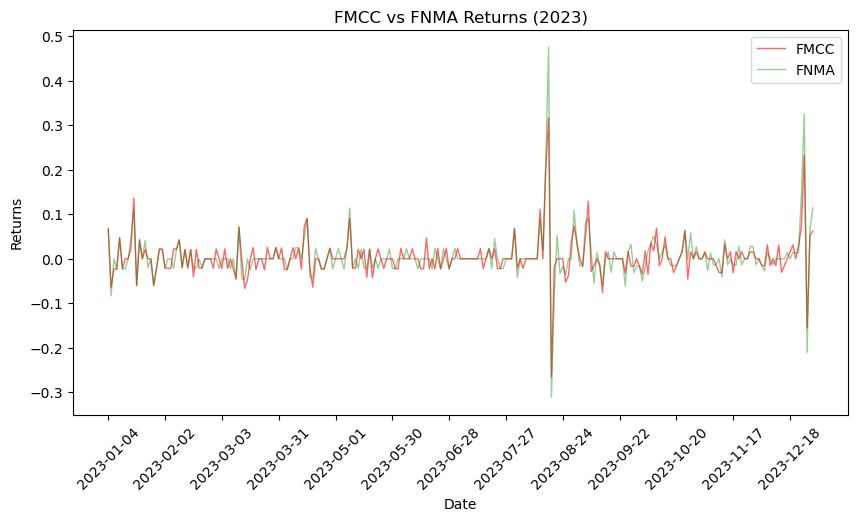

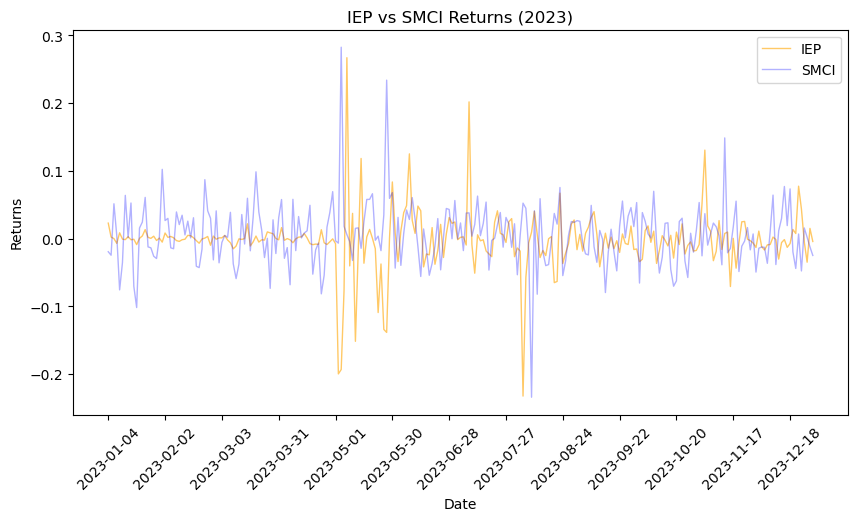

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# search for the highest and lowest covariance values

# Copy the covariance matrix so diagonals can be masked
copyCovMatrix = covMatrix_2023.copy()
np.fill_diagonal(copyCovMatrix.values, np.nan)  # mask diagonal

# Flatten the matrix
flat_values = copyCovMatrix.values.flatten()

# Maximum off-diagonal covariance
maxCov = np.nanmax(flat_values)
row_idx, col_idx = np.unravel_index(np.nanargmax(copyCovMatrix.values), copyCovMatrix.shape)
row_label = copyCovMatrix.index[row_idx]
col_label = copyCovMatrix.columns[col_idx]
print(f"Max value: {maxCov}, row: {row_label}, column: {col_label}")

# Minimum off-diagonal covariance
minCov = np.nanmin(flat_values)
row_idx, col_idx = np.unravel_index(np.nanargmin(copyCovMatrix.values), copyCovMatrix.shape)
row_label = copyCovMatrix.index[row_idx]
col_label = copyCovMatrix.columns[col_idx]
print(f"Min value: {minCov}, row: {row_label}, column: {col_label}")

# graph

returns_2023 = pd.read_csv("returns_2023.csv") # read data again so we get the "Date" column back
returns_2024 = pd.read_csv("returns_2024.csv")

plt.figure(figsize=(10, 5))
plt.plot(returns_2023["Date"], returns_2023["FMCC"], label="FMCC", linewidth=1, alpha=0.6, color='red')
plt.plot(returns_2023["Date"], returns_2023["FNMA"], label="FNMA", linewidth=1, alpha=0.4, color='green')

plt.xlabel("Date")
plt.ylabel("Returns") 
plt.title("FMCC vs FNMA Returns (2023)")
plt.legend()
plt.xticks(returns_2023["Date"].iloc[::20], rotation=45)
# plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(returns_2023["Date"], returns_2023["IEP"], label="IEP", linewidth=1, alpha=0.6, color='orange')
plt.plot(returns_2023["Date"], returns_2023["SMCI"], label="SMCI", linewidth=1, alpha=0.3, color='blue')

plt.xlabel("Date")
plt.ylabel("Returns")  
plt.title("IEP vs SMCI Returns (2023)")
plt.legend()
plt.xticks(returns_2023["Date"].iloc[::20], rotation=45)
# plt.grid(True)
plt.show()


## Section 3.2: Portfolio Optimization

To find the "optimal portfolio", we need to know the specific **stocks** (or assets) and each stock's **weight**. When considering *how many stocks* to have within a portfolio, it's important to consider the implications: adding more stocks reduces idiosyncratic risk, or the possibility of bad outcome for a singular stock impacing the entire portfolio. Studies have shown that most diversification benefit can be achieved with around 20-30 stocks in large-cap US portfolio. 

There is much that goes into deciding what stocks are actually contribute to the best portfolio, and this is the notion we will test later. For now, select a random sample of **10** stocks to use in our portfolio.

The next step now is to identify what the **weight** of each stock should be in the portfolio, or in other words, how much of the portfolio should each stock make up. To do so, there are many approahces. The most popular is Mean-Variance Optimization. Simply put, we are looking for the weights that will result in the portfolio having the highest *sharpe ratio*, which is also known as the tangent portfolio which lies on the *efficient frontier* where it intersects with the *Capital Allocaiton Line (CAL)* representing possible combinations of a risk-free asset. A more detailed explination of these topics can be found in this video: https://www.youtube.com/watch?time_continue=346&v=fWnyg0UeQkg&embeds_referring_euri=https%3A%2F%2Fgemini.google.com%2F&embeds_referring_origin=https%3A%2F%2Fgemini.google.com&source_ve_path=Mjg2NjY

In order to visualize the CAL and efficient frontier, we need to plot our portfolio at different test weights. The formula for Portfolio Expected Return is given by:
$$E_p = \sum_{i=1}^{n} w_i R_i$$

The formula for Portfolio Variance is given by:
$$\sigma_p^2 = \mathbf{w}^T \Sigma \mathbf{w}$$

However, risk is measured in standard deviation as follows:
$$\sigma_p = \sqrt{\mathbf{w}^T \Sigma \mathbf{w}}$$


Our sample portfolio: ['AIZ', 'XEL', 'INGR', 'NEM', 'WDC', 'ET', 'RF', 'ARW', 'CL', 'VFC']
Expected Returns for Sample Portfolio: AIZ     0.001357
XEL    -0.000285
INGR    0.000629
NEM    -0.000358
WDC     0.002340
ET      0.001134
RF      0.000043
ARW     0.000697
CL      0.000185
VFC    -0.000766
dtype: float64


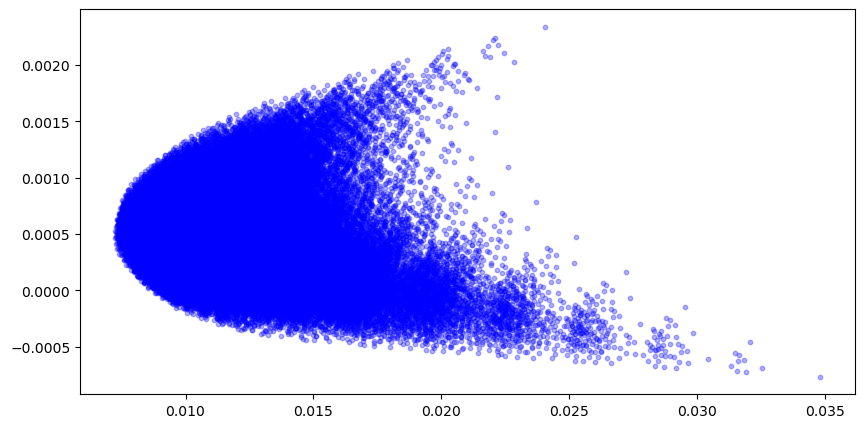

In [211]:
import random
from itertools import combinations_with_replacement

# random sample of 10 stocks
samplePortfolio = random.sample(covMatrix_2023.columns.tolist(), 10)
print(f'Our sample portfolio: {samplePortfolio}')

# calculate the expected return for these stocks
expectedReturn_sample = returns_2023[samplePortfolio].mean()
print(f'Expected Returns for Sample Portfolio: {expectedReturn_sample}')

# get just a list of the expected returns
expectedReturns = expectedReturn_sample.values.tolist()

# get covariance matrix of sample portfolio
samplePortfolioCOV = returns_2023[samplePortfolio].cov()
# print(samplePortfolioCOV)

# to visualize, we will iterate each possible weight in increments of 0.1 for each stock
n = 10
step = 0.1
portfolioWeights = []

def generate_weights(n, total):
    if n == 1:
        yield [total]
    else:
        for i in range(total + 1):
            for rest in generate_weights(n-1, total - i):
                yield[i] + rest

for x in generate_weights(n, 10):
    w = np.array(x) * step
    portfolioWeights.append(w)

# print(len(portfolioWeights))
# print(portfolioWeights[:10])

# calculate points 
returns = [] # y-values
risks = [] # x-values

for combo in portfolioWeights:
    comboReturn = 0
    for i in range(n):
        comboReturn += expectedReturns[i] * combo[i]
        
    returns.append(comboReturn)
    risks.append(np.sqrt(combo.T @ samplePortfolioCOV @ combo))

    
# plot
plt.figure(figsize=(10, 5))
plt.scatter(risks, returns, color='blue', alpha = 0.3, s=10)